# V2_1 · HSMM — Human skeletal-muscle myoblast differentiation

**Data**: `HSMM_fpkm.h5ad` (271 cells × 47192 genes, FPKM) with metadata
for 4 time points (0 / 24 / 48 / 72 h) and a pre-computed `CellType` column.

**Pipeline**:
1. FPKM → Census transcript counts → negative-binomial CellDataSet
2. Cell-level QC filter on `Mapped.Fragments` and `Total_mRNAs`
3. Subset to `CellType == 'Myoblast'`
4. tSNE + density-peak clustering, then `~Cluster` differential test for ordering genes
5. DDRTree + `order_cells` (root = State containing the most Hours==0 cells)
6. Trajectory visualisation, `plot_genes_in_pseudotime`,
   `plot_genes_branched_pseudotime`
7. Pseudotime heatmap on a curated marker panel
8. BEAM → branched gene heatmap

In [1]:
import numpy as np
import pandas as pd

from monocle2py import (
    beam,
    cluster_cells,
    detect_genes,
    differential_gene_test,
    estimate_size_factors,
    load_hsmm_fpkm,
    new_cell_dataset,
    order_cells,
    plot_cell_clusters,
    plot_cell_trajectory,
    plot_genes_branched_heatmap,
    plot_genes_branched_pseudotime,
    plot_genes_in_pseudotime,
    plot_pseudotime_heatmap,
    plot_rho_delta,
    reduce_dimension,
    relative2abs,
    set_ordering_filter,
    tobit,
)
from monocle2py._uns import set_disp_fit_info

## 1. Input — FPKM → Census transcript counts → NB CellDataSet

Monocle2's differential tests and DDRTree assume a negative-binomial count model. FPKM cannot be fed directly into NB, so we first run
`relative2abs` (the Census algorithm) to back-compute transcript counts, then rebuild the CDS with a negative-binomial expression family.

In [2]:
fpkm = load_hsmm_fpkm()
fpkm

AnnData object with n_obs × n_vars = 271 × 47192
    obs: 'Library', 'Well', 'Hours', 'Media', 'Mapped.Fragments', 'Pseudotime', 'State', 'CellType'
    var: 'gene_short_name', 'biotype', 'num_cells_expressed', 'use_for_ordering'
    uns: 'monocle2', 'monocle2_note'

In [3]:
fpkm_cds = new_cell_dataset(
    fpkm.X, pheno_data=fpkm.obs.copy(),
    feature_data=fpkm.var.copy(),
    lower_detection_limit=0.1,
    expression_family=tobit(lower=0.1),
)
rpc = relative2abs(fpkm_cds, method='num_genes')

HSMM = new_cell_dataset(
    rpc, pheno_data=fpkm.obs.copy(),
    feature_data=fpkm.var.copy(),
    lower_detection_limit=0.5,
)
estimate_size_factors(HSMM)
detect_genes(HSMM, min_expr=0.1)
HSMM

AnnData object with n_obs × n_vars = 271 × 47192
    obs: 'Library', 'Well', 'Hours', 'Media', 'Mapped.Fragments', 'Pseudotime', 'State', 'CellType', 'Size_Factor', 'num_genes_expressed'
    var: 'gene_short_name', 'biotype', 'num_cells_expressed', 'use_for_ordering'
    uns: 'monocle2'

## 2. Cell-level QC filter

Three sequential cuts:
- depth: `Mapped.Fragments > 1e6`
- doublet guard: `Total_mRNAs < 1e6`
- log10-mean ± 2σ trim on `Total_mRNAs`

In [4]:
HSMM = HSMM[HSMM.obs['Mapped.Fragments'].astype(float) > 1e6].copy()
HSMM.obs['Total_mRNAs'] = np.asarray(HSMM.X.sum(axis=1)).ravel()
HSMM = HSMM[HSMM.obs['Total_mRNAs'] < 1e6].copy()

log_total = np.log10(HSMM.obs['Total_mRNAs'].to_numpy(float))
upper = 10 ** (log_total.mean() + 2 * log_total.std(ddof=1))
lower = 10 ** (log_total.mean() - 2 * log_total.std(ddof=1))
keep = (HSMM.obs['Total_mRNAs'] > lower) & (HSMM.obs['Total_mRNAs'] < upper)
HSMM = HSMM[keep].copy()
detect_genes(HSMM, min_expr=0.1)
print(f'After QC: cells = {HSMM.n_obs}  genes = {HSMM.n_vars}')
print(f'Total_mRNAs window: [{lower:.0f}, {upper:.0f}]')

After QC: cells = 262  genes = 47192
Total_mRNAs window: [19794, 39569]


## 3. Subset to Myoblasts

The `CellType` column is pre-computed in the input bundle (`MYF5+ → Myoblast` / `ANPEP+ → Fibroblast`), so we filter the CDS directly.

In [5]:
is_myo = (HSMM.obs['CellType'] == 'Myoblast').to_numpy()
HSMM_myo = HSMM[is_myo].copy()
estimate_size_factors(HSMM_myo)
detect_genes(HSMM_myo, min_expr=0.1)
expressed = HSMM_myo.var_names[HSMM_myo.var['num_cells_expressed'] >= 10].tolist()
print(f'Myoblast subset: cells = {HSMM_myo.n_obs}  '
      f'expressed genes (>=10 cells) = {len(expressed)}')

Myoblast subset: cells = 85  expressed genes (>=10 cells) = 10554


## 4. Select ordering genes — tSNE + density-peak clustering → `~Cluster` DEG

Using `~Media` DEGs gives a linear trajectory; the cluster-based path is what exposes the **Cycling Myoblast / Myotube / Reserve cell** branches DDRTree needs.

In [6]:
HSMM_myo.var['use_for_ordering'] = (
    HSMM_myo.var['num_cells_expressed'] > 0.05 * HSMM_myo.n_obs
)

reduce_dimension(
    HSMM_myo, max_components=2, num_dim=3,
    norm_method='log', reduction_method='tSNE',
    perplexity=10, verbose=False,
)
cluster_cells(HSMM_myo, gaussian=True)
print('clusters:', sorted(HSMM_myo.obs['Cluster'].unique().tolist()))

clusters: ['1', '2', '3']


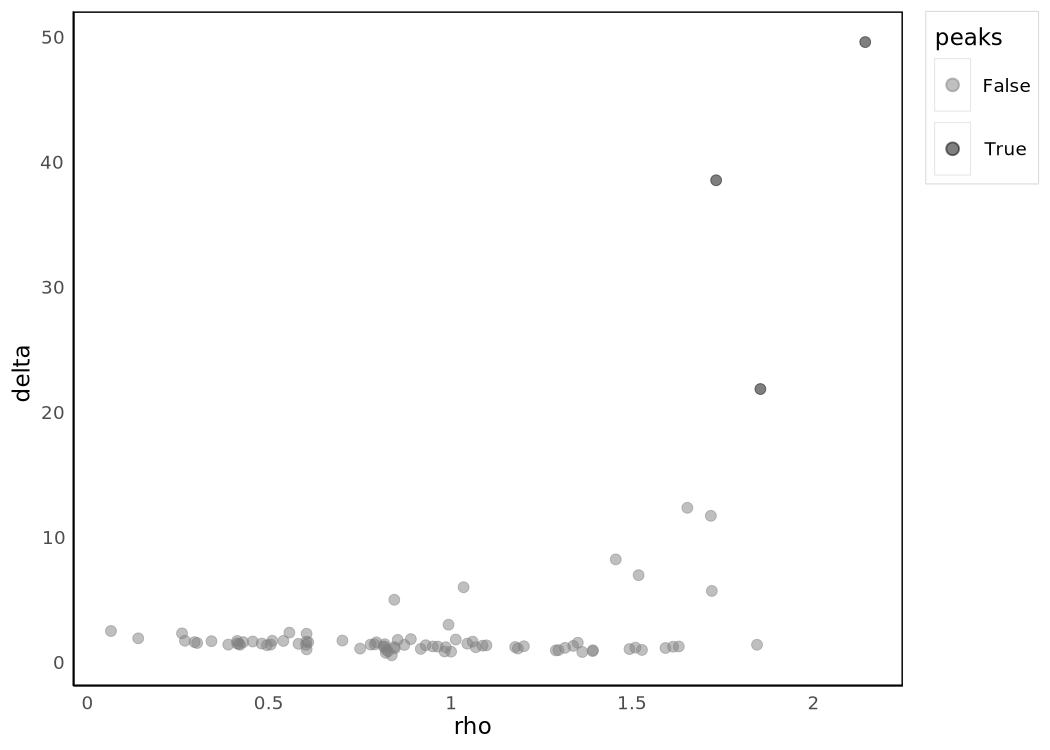

In [7]:
p = plot_rho_delta(HSMM_myo)
p

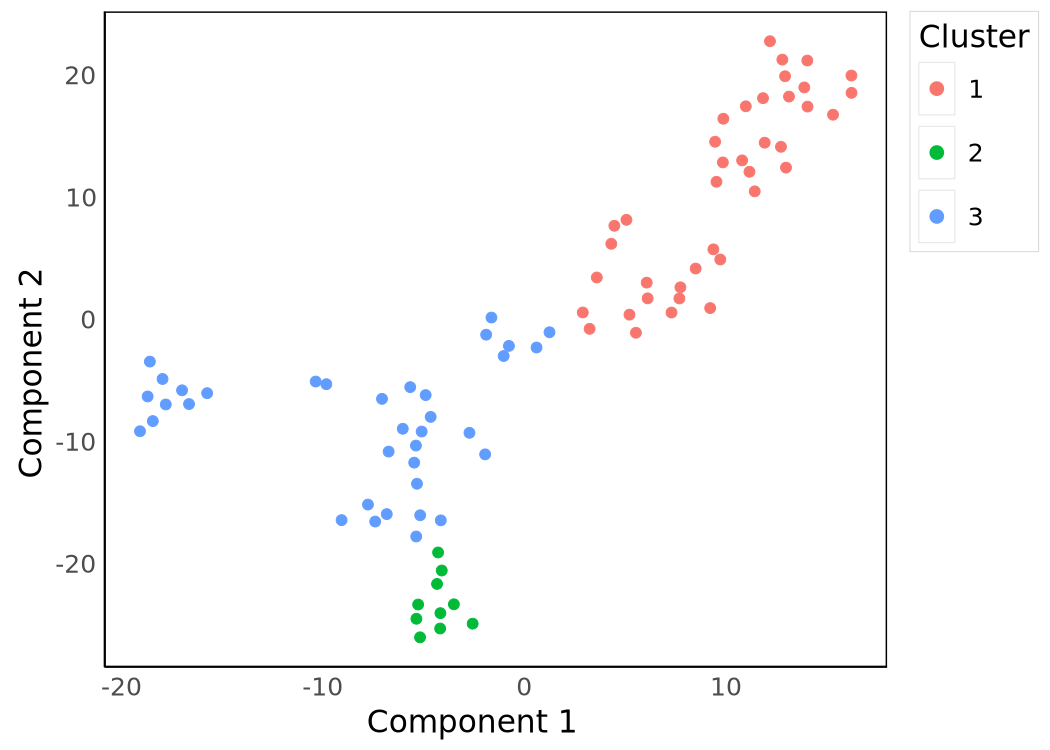

In [8]:
plot_cell_clusters(HSMM_myo)

In [9]:
# Per-Cluster DEG → take top 1000 genes by qval as the ordering filter.
panel = HSMM_myo[:, [g for g in expressed if g in HSMM_myo.var_names][:200]].copy()
panel.uns['monocle2'] = dict(HSMM_myo.uns['monocle2'])

def _disp_func(q):
    return 0.05 + 1.0 / np.asarray(q, dtype=float)
set_disp_fit_info(
    panel,
    {'disp_func': _disp_func,
     'coefficients': {'asymptDisp': 0.05, 'extraPois': 1.0},
     'disp_table': pd.DataFrame()},
    name='blind',
)
clust_DEG = differential_gene_test(panel, '~Cluster', '~1')
ordering_genes = clust_DEG.sort_values('qval').index[:1000].tolist()
set_ordering_filter(HSMM_myo, ordering_genes)
print('ordering genes:', int(HSMM_myo.var['use_for_ordering'].sum()))

ordering genes: 200


## 5. Trajectory inference — DDRTree + `order_cells`

DDRTree projects cells into a 2-D principal-graph space. The first call to
`order_cells` picks the root arbitrarily; we then re-anchor the root to the
State that contains the most `Hours == 0` cells.

In [10]:
reduce_dimension(
    HSMM_myo, max_components=2, reduction_method='DDRTree',
    auto_param_selection=True, max_iter=10, verbose=False,
)
order_cells(HSMM_myo)

AnnData object with n_obs × n_vars = 85 × 47192
    obs: 'Library', 'Well', 'Hours', 'Media', 'Mapped.Fragments', 'Pseudotime', 'State', 'CellType', 'Size_Factor', 'num_genes_expressed', 'Total_mRNAs', 'Cluster', 'peaks', 'halo', 'delta', 'rho', 'nearest_higher_density_neighbor', 'Parent'
    var: 'gene_short_name', 'biotype', 'num_cells_expressed', 'use_for_ordering'
    uns: 'monocle2'
    obsm: 'X_dr'

In [11]:
def gm_state(adata):
    if adata.obs['State'].nunique() <= 1:
        return 1
    t0 = (
        adata.obs[adata.obs['Hours'].astype(float) == 0.0]['State']
        .astype(int).value_counts()
    )
    return int(t0.idxmax()) if not t0.empty else int(adata.obs['State'].astype(int).iloc[0])

order_cells(HSMM_myo, root_state=gm_state(HSMM_myo))
print('States:', sorted(HSMM_myo.obs['State'].astype(int).unique().tolist()))

States: [1, 2, 3, 4, 5]


## 6. Trajectory visualisation

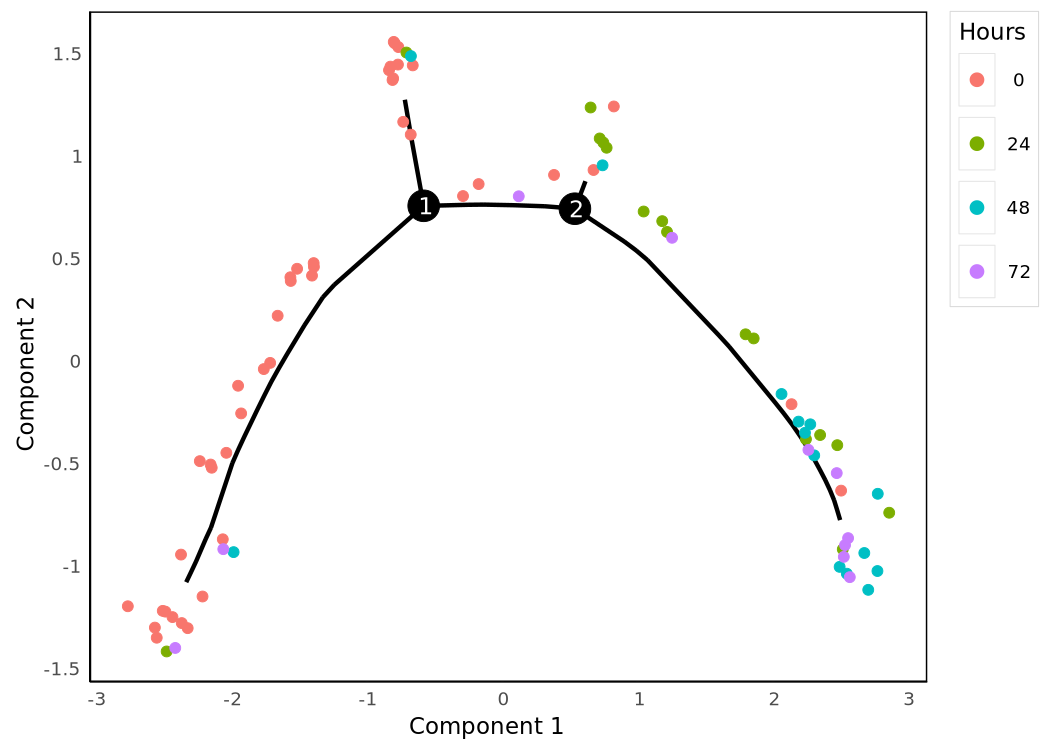

In [12]:
HSMM_myo.obs['Hours'] = HSMM_myo.obs['Hours'].astype('category')
plot_cell_trajectory(HSMM_myo, color_by='Hours')

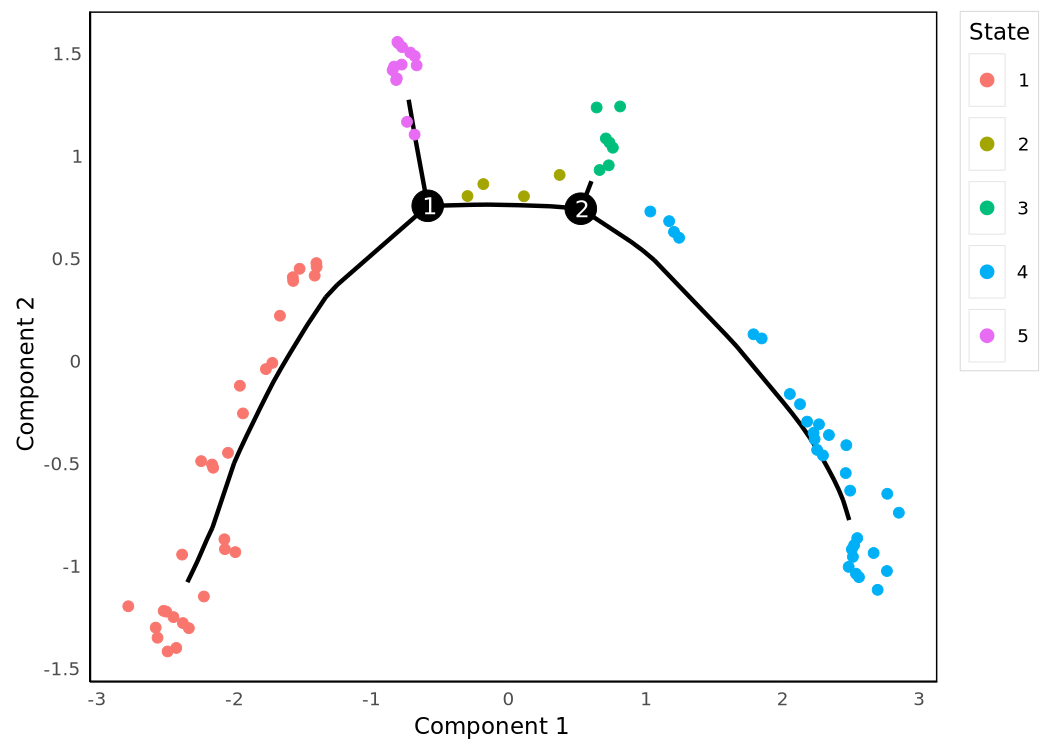

In [13]:
plot_cell_trajectory(HSMM_myo, color_by='State')

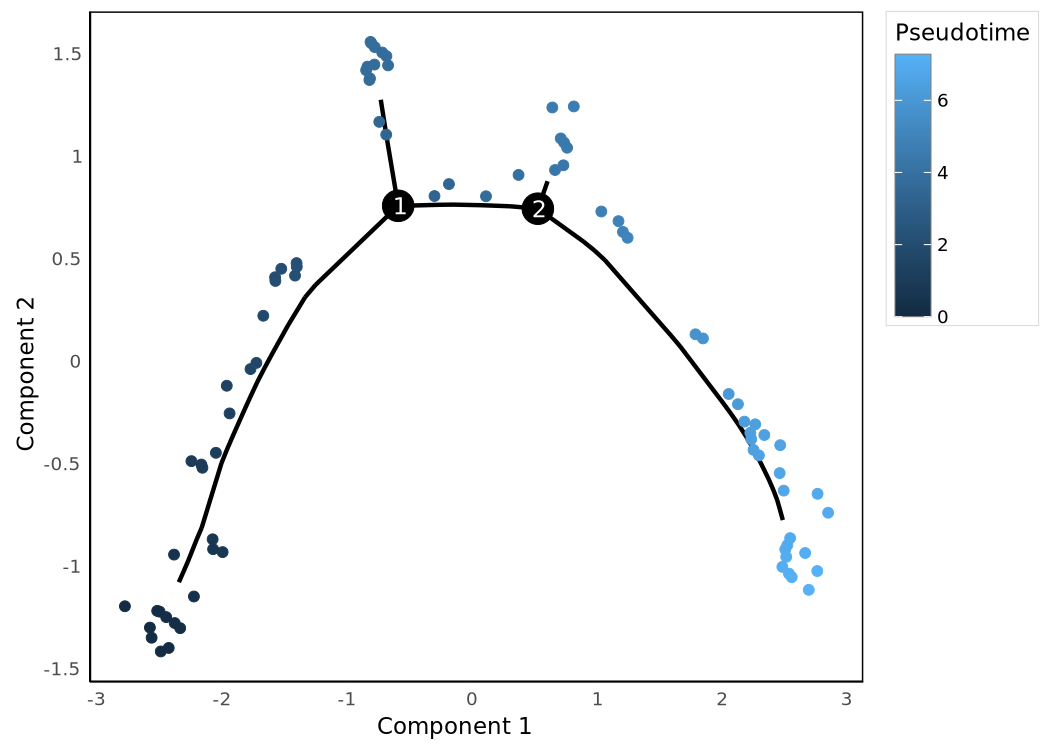

In [14]:
plot_cell_trajectory(HSMM_myo, color_by='Pseudotime', show_branch_points=True)

##### Single-gene curves — whole pseudotime and branched

`plot_genes_in_pseudotime` shows the smoothed expression of a gene along the
full pseudotime axis; `plot_genes_branched_pseudotime` splits at the branch
point and draws one curve per child branch.

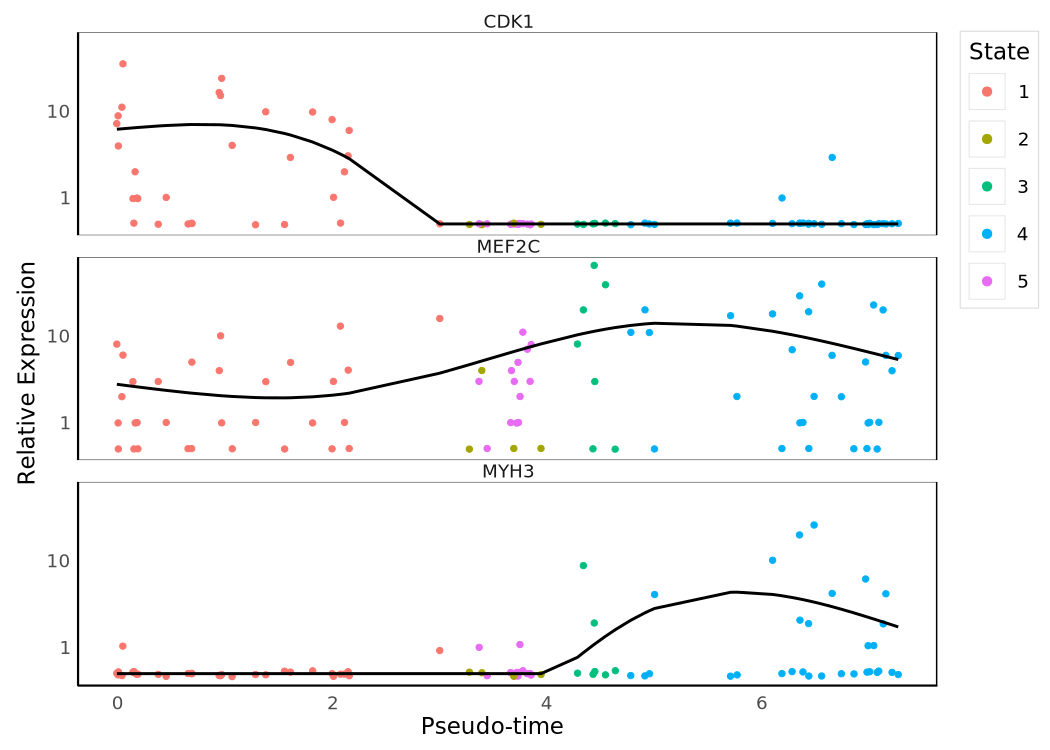

In [15]:
marker_short = ['CDK1', 'MEF2C', 'MYH3']
my_genes = HSMM_myo.var_names[
    HSMM_myo.var['gene_short_name'].isin(marker_short)
].tolist()
plot_genes_in_pseudotime(HSMM_myo[:, my_genes])

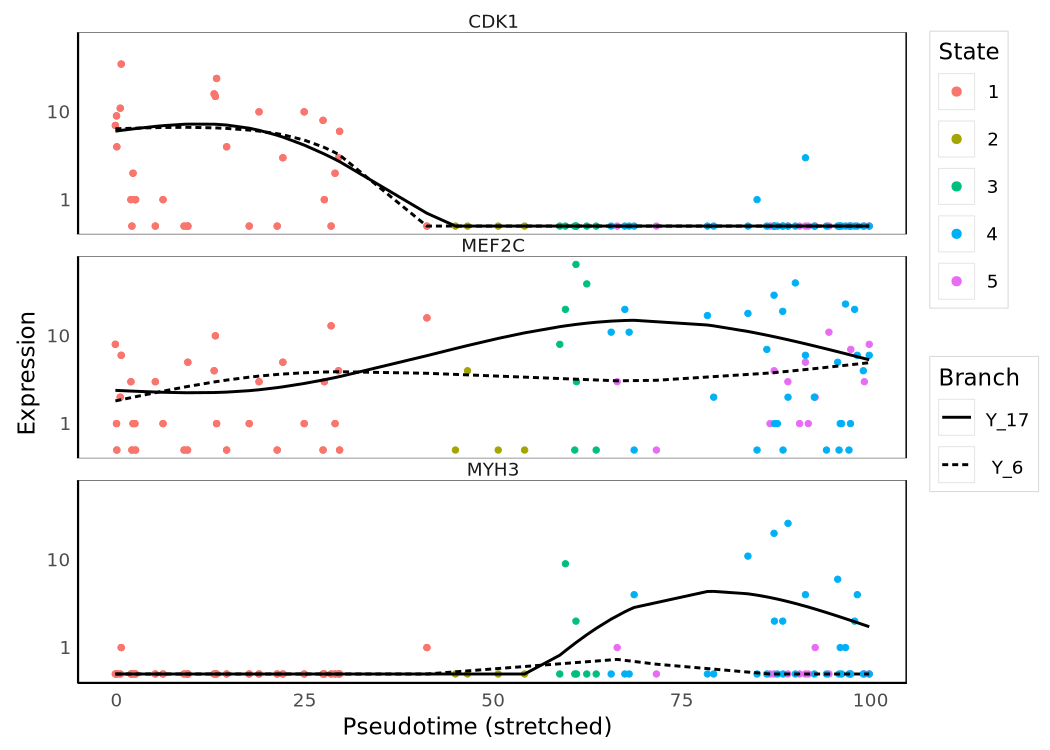

In [16]:
plot_genes_branched_pseudotime(
    HSMM_myo[:, my_genes], branch_point=1, ncol=1,
)

In [17]:
from grid_py import grid_newpage, grid_draw                                                                                                                                                                                                         
from grid_py._state import get_state                                                                                                                                                                                                                  
from IPython.display import Image, display

def show(ph, width=12, height=8, dpi=100):                                                                                                                                                                                                            
  grid_newpage(width=width, height=height, dpi=dpi)
  grid_draw(ph.gtable)                                                                                                                                                                                                                              
  display(Image(data=get_state().get_renderer().to_png_bytes(), format="png"))

## 8. Pseudotime heatmap on a curated marker panel

We test a list of muscle / cell-cycle markers for pseudotime dependence with
`differential_gene_test('~sm.ns(Pseudotime, df=3)', '~1')` and feed the
significant hits into `plot_pseudotime_heatmap`.

pt-dependent markers (qval<0.1): 18


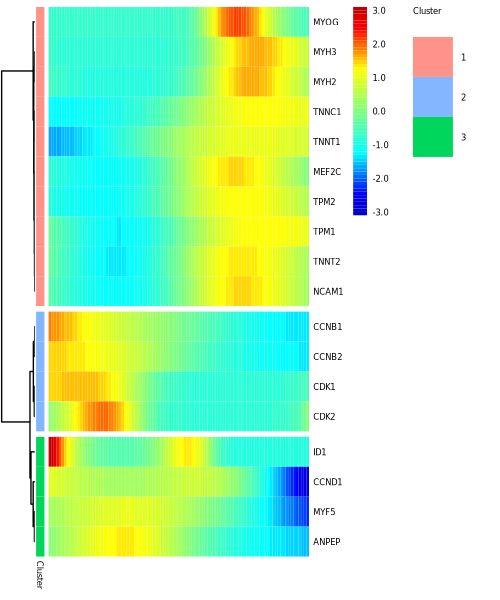

In [18]:
marker_panel_short = [
    'MEF2C', 'MEF2D', 'MYF5', 'ANPEP', 'PDGFRA', 'MYOG',
    'TPM1', 'TPM2', 'MYH2', 'MYH3', 'NCAM1',
    'TNNT1', 'TNNT2', 'TNNC1',
    'CDK1', 'CDK2', 'CCNB1', 'CCNB2', 'CCND1', 'CCNA1', 'ID1',
]
marker_genes = HSMM_myo.var_names[
    HSMM_myo.var['gene_short_name'].isin(marker_panel_short)
].tolist()
marker_cds = HSMM_myo[:, marker_genes].copy()
marker_cds.uns['monocle2'] = dict(HSMM_myo.uns['monocle2'])
set_disp_fit_info(
    marker_cds,
    {'disp_func': _disp_func,
     'coefficients': {'asymptDisp': 0.05, 'extraPois': 1.0},
     'disp_table': pd.DataFrame()},
    name='blind',
)
pt_test = differential_gene_test(marker_cds, '~sm.ns(Pseudotime, df=3)', '~1')
sig_pt = pt_test[pt_test['qval'] < 0.1].sort_values('qval').index.tolist()
print('pt-dependent markers (qval<0.1):', len(sig_pt))
ph = plot_pseudotime_heatmap(
    HSMM_myo[:, sig_pt], num_clusters=3,
    norm_method='log', show_rownames=True,
)
show(ph, width=5, height=6)

## 9. BEAM — branch-dependent genes

BEAM tests each gene for differential expression dynamics between the two
child branches at `branch_point=1` via a likelihood-ratio test on a smoothed
model with branch interaction vs. without.

In [19]:
panel.uns['monocle2'] = dict(HSMM_myo.uns['monocle2'])
set_disp_fit_info(
    panel,
    {'disp_func': _disp_func,
     'coefficients': {'asymptDisp': 0.05, 'extraPois': 1.0},
     'disp_table': pd.DataFrame()},
    name='blind',
)
beam_res = beam(panel, branch_point=1)
beam_res = beam_res.sort_values('qval')
print('genes tested:', len(beam_res),
      '| qval<1e-3:', int((beam_res['qval'] < 1e-3).sum()))
beam_res[['gene_short_name', 'pval', 'qval']].head(15)

genes tested: 200 | qval<1e-3: 2


,gene_short_name,pval,qval
gene_id,,,
ENSG00000011465.12,DCN,9.994940e-19,1.549216e-16
ENSG00000005022.5,SLC25A5,1.834218e-07,1.421519e-05
ENSG00000006042.7,TMEM98,9.329383e-05,4.820181e-03
ENSG00000010270.9,STARD3NL,2.721730e-04,1.054671e-02
ENSG00000013588.5,GPRC5A,4.649878e-04,1.441462e-02
ENSG00000012660.9,ELOVL5,8.145960e-04,2.104373e-02
ENSG00000005955.8,GGNBP2,1.731412e-03,3.354611e-02
ENSG00000010244.12,ZNF207,1.712730e-03,3.354611e-02
ENSG00000006837.6,CDKL3,2.062241e-03,3.364404e-02


In [20]:
top_branch_genes = beam_res[beam_res['qval'] < 1e-3].index.tolist()
if len(top_branch_genes) >= 5:
    plot_genes_branched_heatmap(
        HSMM_myo[:, top_branch_genes], branch_point=1,
        num_clusters=3, use_gene_short_name=True,
        show_rownames=len(top_branch_genes) < 40,
    )
else:
    print('Fewer than 5 BEAM hits at qval<1e-3 — skipping heatmap.')

Fewer than 5 BEAM hits at qval<1e-3 — skipping heatmap.
